In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path

In [115]:
def load_dataset(root_path, classes=None, expected_shape=None):
    """
    Loads .npy patches from subdirectories.
    
    Args:
        root_path (str): Path to the folder containing class folders.
        classes (list, optional): List of class names to load. 
                                  If None, defaults to ['background', 'hold_hole', 'wall_hole'].
        expected_shape (tuple, optional): If provided, skips files that do not match this shape.
        
    Returns:
        X (np.array): Shape (N_samples, ...)
        y (np.array): Shape (N_samples, )
        class_names (list): The list of classes used for mapping.
    """
    root = Path(root_path)
    
    if classes is None:
        classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
        print(f"Auto-detected classes: {classes}")
    
    X_list = []
    y_list = []
    
    print(f"Loading data from {root}...")
    
    for class_id, class_name in enumerate(classes):
        class_dir = root / class_name
        
        if not class_dir.exists():
            print(f"Warning: Folder '{class_name}' not found in {root}")
            continue
            
        files = list(class_dir.glob('*.npy'))
        print(f"  Found {len(files)} samples for class '{class_name}' (ID: {class_id})")
        
        for file_path in files:
            try:
                patch = np.load(file_path)

                if expected_shape is not None and patch.shape != expected_shape:
                    print(f"Skipping {file_path.name}: shape {patch.shape} != {expected_shape}")
                    continue
                    
                X_list.append(patch)
                y_list.append(class_id)
                
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    X = np.array(X_list)
    y = np.array(y_list)
    
    print("-" * 30)
    print(f"Data Loaded.")
    print(f"X Shape: {X.shape}") 
    print(f"y Shape: {y.shape}")
    
    return X, y, classes

In [116]:
X_train, y_train, classes = load_dataset(r"C:\Users\yana\projects\dyno_or_no\app\data\dataset\train", expected_shape=(64, 64, 13))
X_test, y_test, classes = load_dataset(r"C:\Users\yana\projects\dyno_or_no\app\data\dataset\test", expected_shape=(64, 64, 13))
X_val, y_val, classes = load_dataset(r"C:\Users\yana\projects\dyno_or_no\app\data\dataset\val", expected_shape=(64, 64, 13))

Auto-detected classes: ['background', 'hold_hole', 'wall_hole']
Loading data from C:\Users\yana\projects\dyno_or_no\app\data\dataset\train...
  Found 311 samples for class 'background' (ID: 0)
  Found 198 samples for class 'hold_hole' (ID: 1)
  Found 509 samples for class 'wall_hole' (ID: 2)
------------------------------
Data Loaded.
X Shape: (1018, 64, 64, 13)
y Shape: (1018,)
Auto-detected classes: ['background', 'hold_hole', 'wall_hole']
Loading data from C:\Users\yana\projects\dyno_or_no\app\data\dataset\test...
  Found 69 samples for class 'background' (ID: 0)
  Found 43 samples for class 'hold_hole' (ID: 1)
  Found 110 samples for class 'wall_hole' (ID: 2)
------------------------------
Data Loaded.
X Shape: (222, 64, 64, 13)
y Shape: (222,)
Auto-detected classes: ['background', 'hold_hole', 'wall_hole']
Loading data from C:\Users\yana\projects\dyno_or_no\app\data\dataset\val...
  Found 66 samples for class 'background' (ID: 0)
  Found 42 samples for class 'hold_hole' (ID: 1)
  

In [117]:
def downsample_and_linear_reshape(np_arr):
    arr_downsampled = np_arr[:, ::4,   ::4,   :]
    print(arr_downsampled[0].shape)
    arr_downsampled_reshaped = arr_downsampled.reshape(arr_downsampled.shape[0], -1) 
    return arr_downsampled_reshaped

In [118]:
X_train_ds_reshaped = downsample_and_linear_reshape(X_train)
X_val_ds_reshaped = downsample_and_linear_reshape(X_val)
X_test_ds_reshaped = downsample_and_linear_reshape(X_test)

(16, 16, 13)
(16, 16, 13)
(16, 16, 13)


In [119]:
model = RandomForestClassifier(n_estimators=100)

In [120]:
model.fit(X_train_ds_reshaped, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [121]:
y_pred = model.predict(X_test_ds_reshaped)

In [122]:
y_pred.shape

(222,)

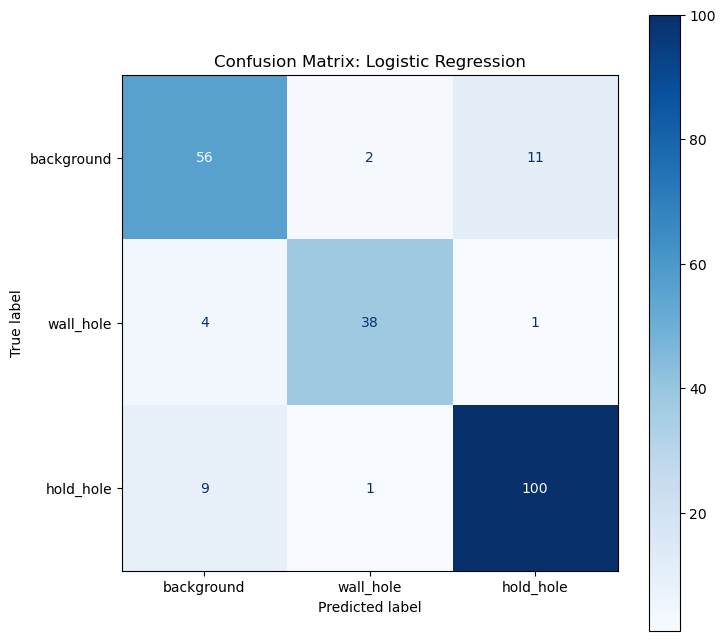

In [123]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Define your class names for the plot axis
# Ensure these match the order: 0, 1, 2
class_names = ['background', 'wall_hole', 'hold_hole']

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Make it big enough to read
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

In [84]:
cm

array([[ 54,   2,  13],
       [  2,  37,   4],
       [  2,   3, 105]])

In [100]:
cm

array([[55,  2, 12],
       [ 2, 40,  1],
       [10,  1, 99]])

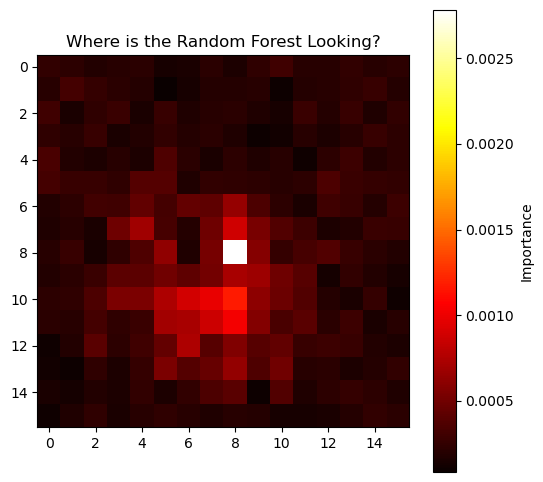

In [107]:
importances = model.feature_importances_

importances_3d = importances.reshape(16, 16, 13)

# 2. Collapse channels to see spatial importance
# "Which pixels matter most regardless of the feature channel?"
spatial_importance = np.mean(importances_3d, axis=2)

# 3. Plot
plt.figure(figsize=(6, 6))
plt.imshow(spatial_importance, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importance')
plt.title("Where is the Random Forest Looking?")
plt.show()

In [89]:
X_train_ds_reshaped[0].shape

(4096,)